# FSSK Exact Validation

## Overview
This notebook validates four properties of the implementation:

| Section | What is tested |
|---|---|
| **0** | Factorial-scaled signature statistics vs. step size $\Delta t$ |
| **1** | $\Lambda = 0$ special case: $\mathrm{SSS}_{\Lambda=0}(X) = \mathrm{Sig}(AX)$ |
| **2** | First-order Euler convergence to exact FSSK as $\Delta t \to 0$ |
| **3** | XLA FLOP count scales linearly with predicted work $W_q$ |

All scripts live in `validation/`; outputs are written to `validation/validation_outputs/`.

In [3]:
OUTPUT_DIR = "validation_outputs"

## 0. Factorial-scaled signature statistics

The degree-$n$ signature term $\mathrm{Sig}(X)^n \in (\mathbb{R}^d)^{\otimes n}$ has entries of order at most
$(n!)^{-1} \|X\|_{\mathrm{1\text{-}var}}^n$.  Multiplying by $n!$ yields entries of more uniform order
$\|X\|_{\mathrm{1\text{-}var}}^n$, which for **unit-speed** paths (total variation $\approx T$) is $O(1)$.

We generate a large batch of unit-speed paths at several step sizes $\Delta t$ and plot,
for each signature level $n = 1, \ldots, N$:

- **mean norm** — $\mathbb{E}\bigl[\|n!\,\mathrm{Sig}(X)^n\|\bigr]$
- **std** — $\mathrm{std}\bigl[n!\,\mathrm{Sig}(X)^n\bigr]$ (over all entries and paths)

Both quantities should be $O(1)$ and largely independent of $\Delta t$ for unit-speed paths.

  Saved: validation/validation_outputs/signature_level_stats_by_dt.pdf
  Saved: validation/validation_outputs/signature_level_stats_by_dt.png


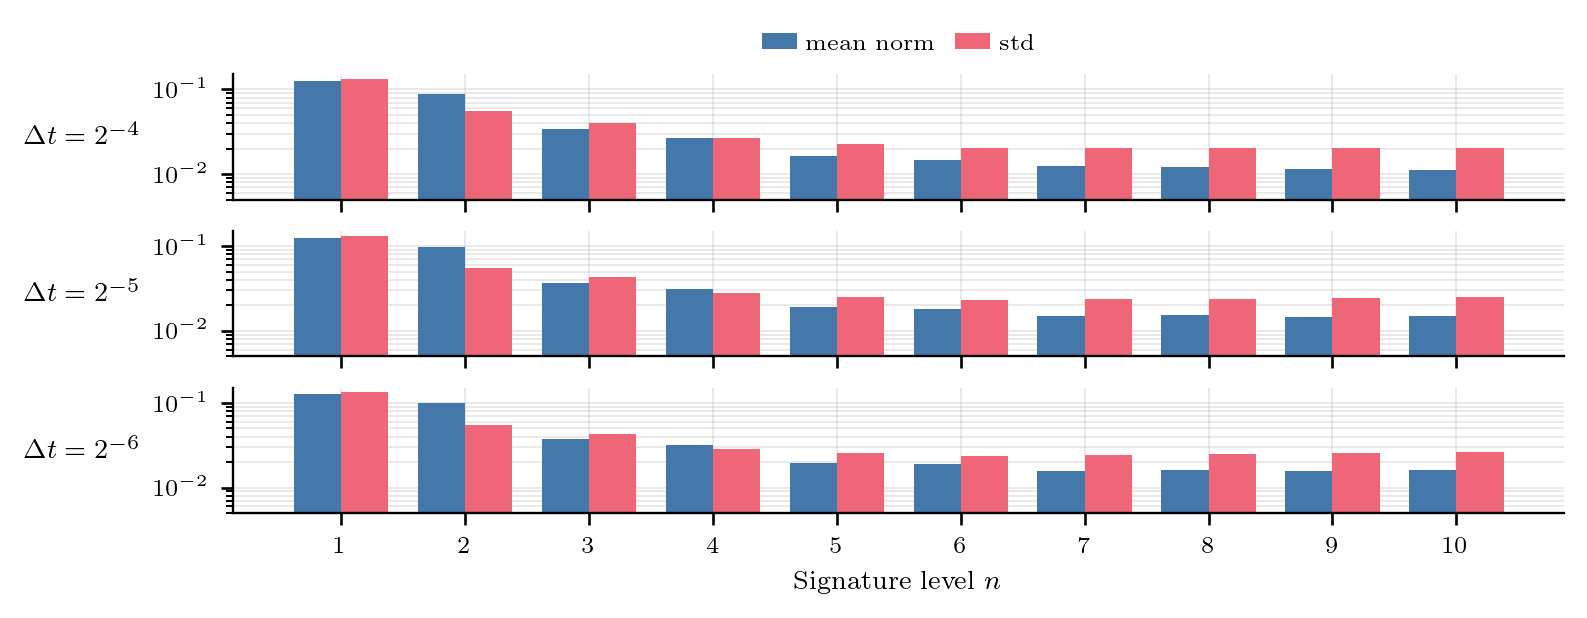

In [4]:
import matplotlib.pyplot as plt
from pathlib import Path
import _validation_util.plot_config  # applies rcParams
from _validation_util.plot_config import FULL_WIDTH, COLORS, savefig_fig

dt_values = df["dt"].drop_duplicates().to_list()[1:]  # skip coarsest
n_dt = len(dt_values)

ROW_HEIGHT = 0.82  # inches per row
fig, axes = plt.subplots(n_dt, 1, figsize=(FULL_WIDTH, ROW_HEIGHT * n_dt), sharex=True)

if n_dt == 1:
    axes = [axes]

bar_width = 0.38

for ax, dt in zip(axes, dt_values):
    g = df[df["dt"] == dt]
    x = g["level"].to_numpy()
    ax.bar(x - bar_width / 2, g["mean_norm"], width=bar_width, color=COLORS[0], label="mean norm")
    ax.bar(x + bar_width / 2, g["std"],       width=bar_width, color=COLORS[1], label="std")
    ax.set_yscale("log")
    ax.set_ylabel(rf"$\Delta t = {dt.strip('$')}$", rotation=0, ha="right", va="center")
    ax.grid(True, axis="y", which="both")
    ax.set_ylim(0.5e-2, 1.5e-1)

axes[-1].set_xlabel(r"Signature level $n$")
axes[-1].set_xticks(range(1, trunc + 1))
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.5), ncol=2, frameon=False)

out_path = Path('validation') / OUTPUT_DIR
out_path.mkdir(parents=True, exist_ok=True)
savefig_fig(fig, out_path / "signature_level_stats_by_dt", ["pdf", "png"])
plt.show()

## 1. Λ = 0 correctness check

When $\Lambda = 0$ the matrix exponential $e^{\Lambda \Delta t} = I$ for all $\Delta t$, and the
state-space recursion collapses to a plain iterated integral.  Concretely, with $Y_t = A X_t \in \mathbb{R}^m$,

$$
\mathrm{SSS}_{\Lambda=0}(X)^n \;=\; \mathrm{Sig}(Y)^n, \qquad n = 1, \ldots, N.
$$

We verify this to **float64 precision** (max absolute error $< 10^{-12}$) for several
$(q, R, m, d)$ configurations.

## 2. Euler convergence

The exact FSSK is evaluated via a **matrix-exponential recursion** along the path grid.
An alternative is the **Euler scheme**: replace $e^{\Lambda \Delta t} \approx I + \Lambda \Delta t$
at each step.  This is first-order accurate, so refining the grid by a factor of 2 (one dyadic
level) should halve the error:

$$
\bigl\|\mathrm{SSS}_{\mathrm{Euler},k}(X) - \mathrm{SSS}_{\mathrm{exact}}(X)\bigr\|
\;=\; O(2^{-k}), \qquad k = 0, 1, 2, \ldots
$$

We fix the coarse grid ($J$ points, $d$-dimensional paths) and sweep dyadic refinement orders
$k = 0, \ldots, k_{\max}$.  For each setup $(q, R)$ and each signature level $n$ we plot

$$
n! \cdot \max_{\text{paths},\,\text{entries}} \bigl|S^n_{\mathrm{exact}} - S^n_{\mathrm{Euler},k}\bigr|
$$

against $k$ on a log scale.  A slope of $-1$ confirms first-order convergence.

In [6]:
# -- Parameters (edit here) --
J          = 16    # coarse path grid points (J-1 increments)
N          = 7     # signature truncation level
m          = 3     # latent-path dimension
d          = 3     # input-path dimension
n_paths    = 128   # batch size
max_dyadic = 8     # sweep dyadic orders 0 ... max_dyadic
path_seed  = 20226 # RNG seed for path generation

# Jordan block parameters passed to random_fssk
eig_min        = 0.1   # min real part (decay) of eigenvalues
eig_max        = 1.0   # max real part (decay) of eigenvalues
freq_min       = 0.25   # min imaginary part (frequency) of oscillatory eigenvalues
freq_max       = 1.0   # max imaginary part (frequency) of oscillatory eigenvalues
min_block_size = 1     # minimum Jordan chain order
max_block_size = 4     # maximum Jordan chain order

setups = [
    {"n": 1, "R": 1, "seed": 412},
    {"n": 2, "R": 2, "seed": 431},
    {"n": 4, "R": 3, "seed": 144},
]

In [7]:
import subprocess, sys, json
from pathlib import Path

common_args = [
    '--J',              str(J),
    '--N',              str(N),
    '--m',              str(m),
    '--n-paths',        str(n_paths),
    '--max-dyadic',     str(max_dyadic),
    '--path-seed',      str(path_seed),
    '--setups',         json.dumps(setups),
    '--eig-min',        str(eig_min),
    '--eig-max',        str(eig_max),
    '--freq-min',       str(freq_min),
    '--freq-max',       str(freq_max),
    '--min-block-size', str(min_block_size),
    '--max-block-size', str(max_block_size),
    '--output-dir',     str(Path('validation') / OUTPUT_DIR),
]

sweep = Path('validation/sweep_euler_convergence.py').resolve()
result = subprocess.run(
    [sys.executable, str(sweep)] + common_args,
    cwd=str(sweep.parent.parent),
    capture_output=False,
)
if result.returncode != 0:
    raise RuntimeError(f'sweep_euler_convergence.py failed with exit code {result.returncode}')

analyse = Path('validation/analyse_euler_convergence.py').resolve()
result = subprocess.run(
    [sys.executable, str(analyse), '--output-dir', str(Path('validation') / OUTPUT_DIR)],
    cwd=str(analyse.parent.parent),
    capture_output=False,
)
if result.returncode != 0:
    raise RuntimeError(f'analyse_euler_convergence.py failed with exit code {result.returncode}')


── n=1, R=1 ──────────────────────────────
  dyadic=0  lvl1=4.72e-03  lvl2=2.64e-02  lvl3=1.15e-02  lvl4=8.88e-03  lvl5=5.08e-03  lvl6=4.07e-03  lvl7=2.98e-03
  dyadic=1  lvl1=2.33e-03  lvl2=1.28e-02  lvl3=5.70e-03  lvl4=4.38e-03  lvl5=2.77e-03  lvl6=2.06e-03  lvl7=1.52e-03
  dyadic=2  lvl1=1.16e-03  lvl2=6.31e-03  lvl3=2.84e-03  lvl4=2.17e-03  lvl5=1.44e-03  lvl6=1.03e-03  lvl7=7.96e-04
  dyadic=3  lvl1=5.76e-04  lvl2=3.13e-03  lvl3=1.41e-03  lvl4=1.08e-03  lvl5=7.30e-04  lvl6=5.14e-04  lvl7=4.08e-04
  dyadic=4  lvl1=2.87e-04  lvl2=1.56e-03  lvl3=7.06e-04  lvl4=5.39e-04  lvl5=3.68e-04  lvl6=2.57e-04  lvl7=2.06e-04
  dyadic=5  lvl1=1.44e-04  lvl2=7.79e-04  lvl3=3.53e-04  lvl4=2.70e-04  lvl5=1.85e-04  lvl6=1.30e-04  lvl7=1.04e-04
  dyadic=6  lvl1=7.18e-05  lvl2=3.89e-04  lvl3=1.76e-04  lvl4=1.35e-04  lvl5=9.25e-05  lvl6=6.55e-05  lvl7=5.20e-05
  dyadic=7  lvl1=3.59e-05  lvl2=1.95e-04  lvl3=8.82e-05  lvl4=6.74e-05  lvl5=4.63e-05  lvl6=3.29e-05  lvl7=2.61e-05
  dyadic=8  lvl1=1.79e-05  l

-- Convergence rates (fitted log2 slope per setup x level) --


,label,q,R,level,slope,intercept_log2
0,"n=1, R=1",1,1,1,-1.004068,-7.741892
1,"n=1, R=1",1,1,2,-1.008460,-5.275667
2,"n=1, R=1",1,1,3,-1.002758,-6.451970
3,"n=1, R=1",1,1,4,-1.003970,-6.832797
4,"n=1, R=1",1,1,5,-0.978665,-7.527489
5,"n=1, R=1",1,1,6,-0.994034,-7.937531
6,"n=1, R=1",1,1,7,-0.979629,-8.356439
7,"n=2, R=2",2,2,1,-1.006318,-6.888016
8,"n=2, R=2",2,2,2,-1.012607,-5.508933
9,"n=2, R=2",2,2,3,-1.013730,-5.762733



-- Scaled max errors  n! * max|S^n_exact - S^n_Euler| --
euler_conv_demo_n_1_R_1


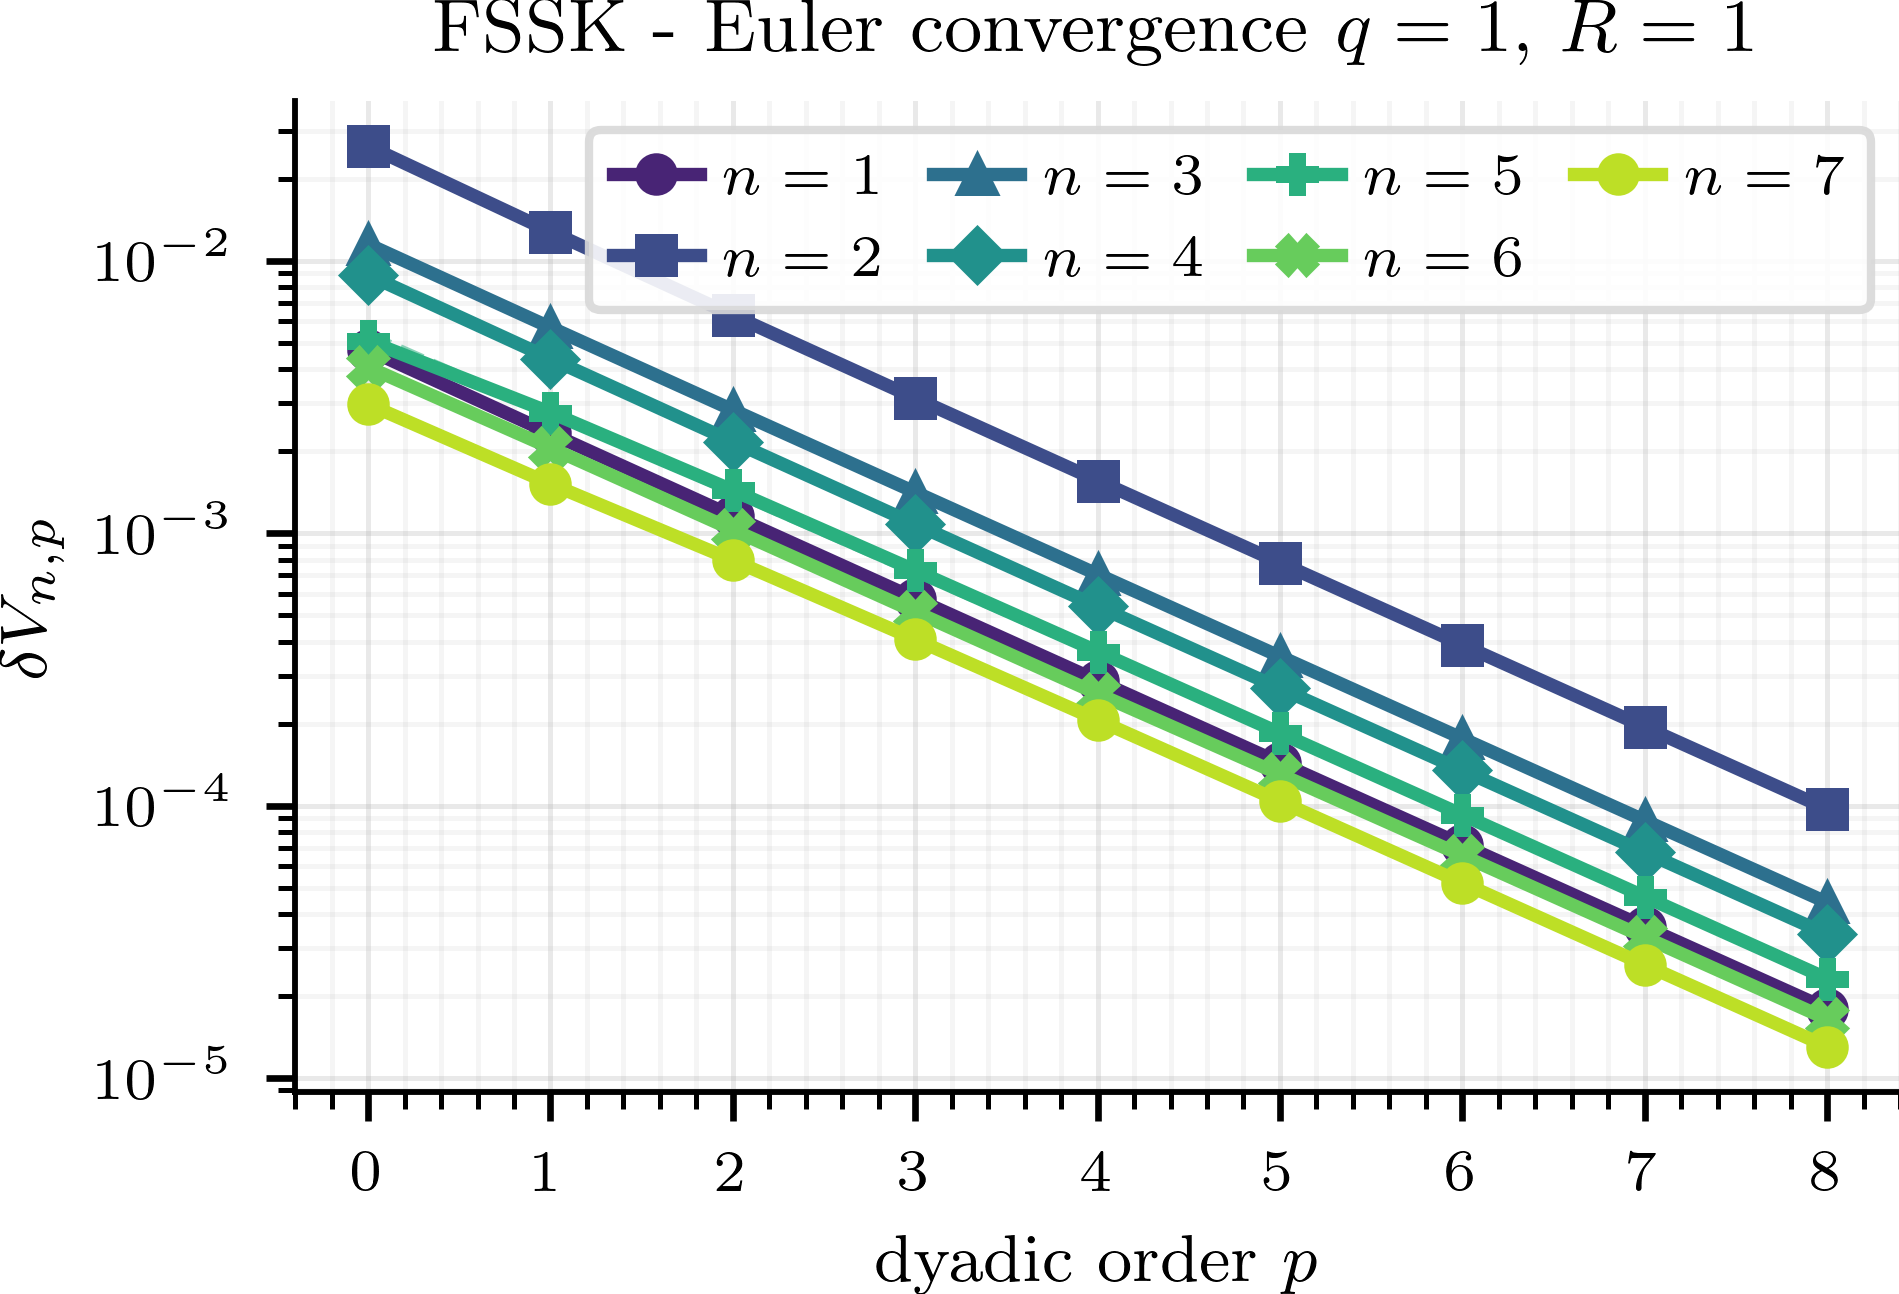

euler_conv_demo_n_2_R_2


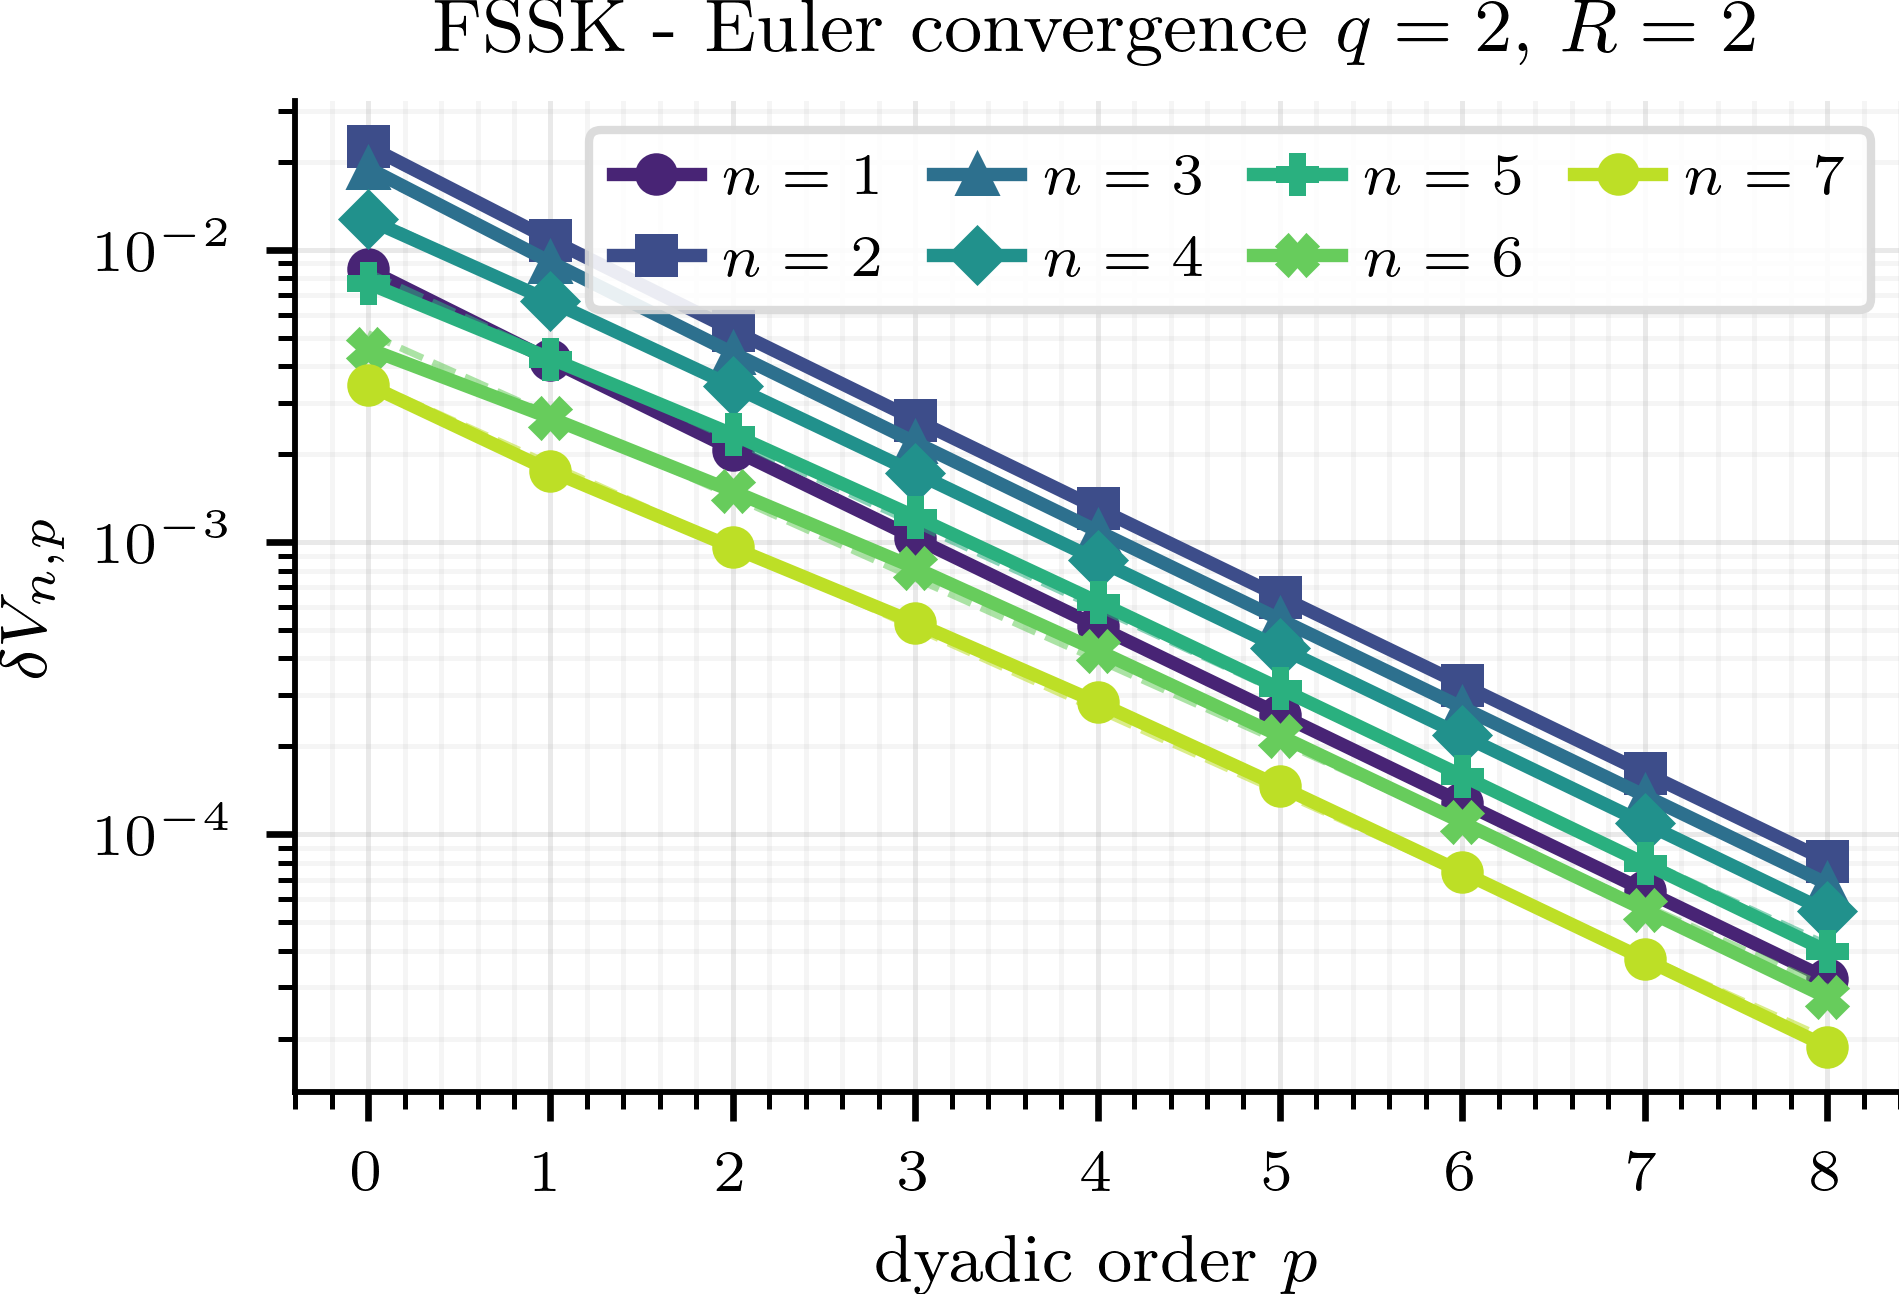

euler_conv_demo_n_4_R_3


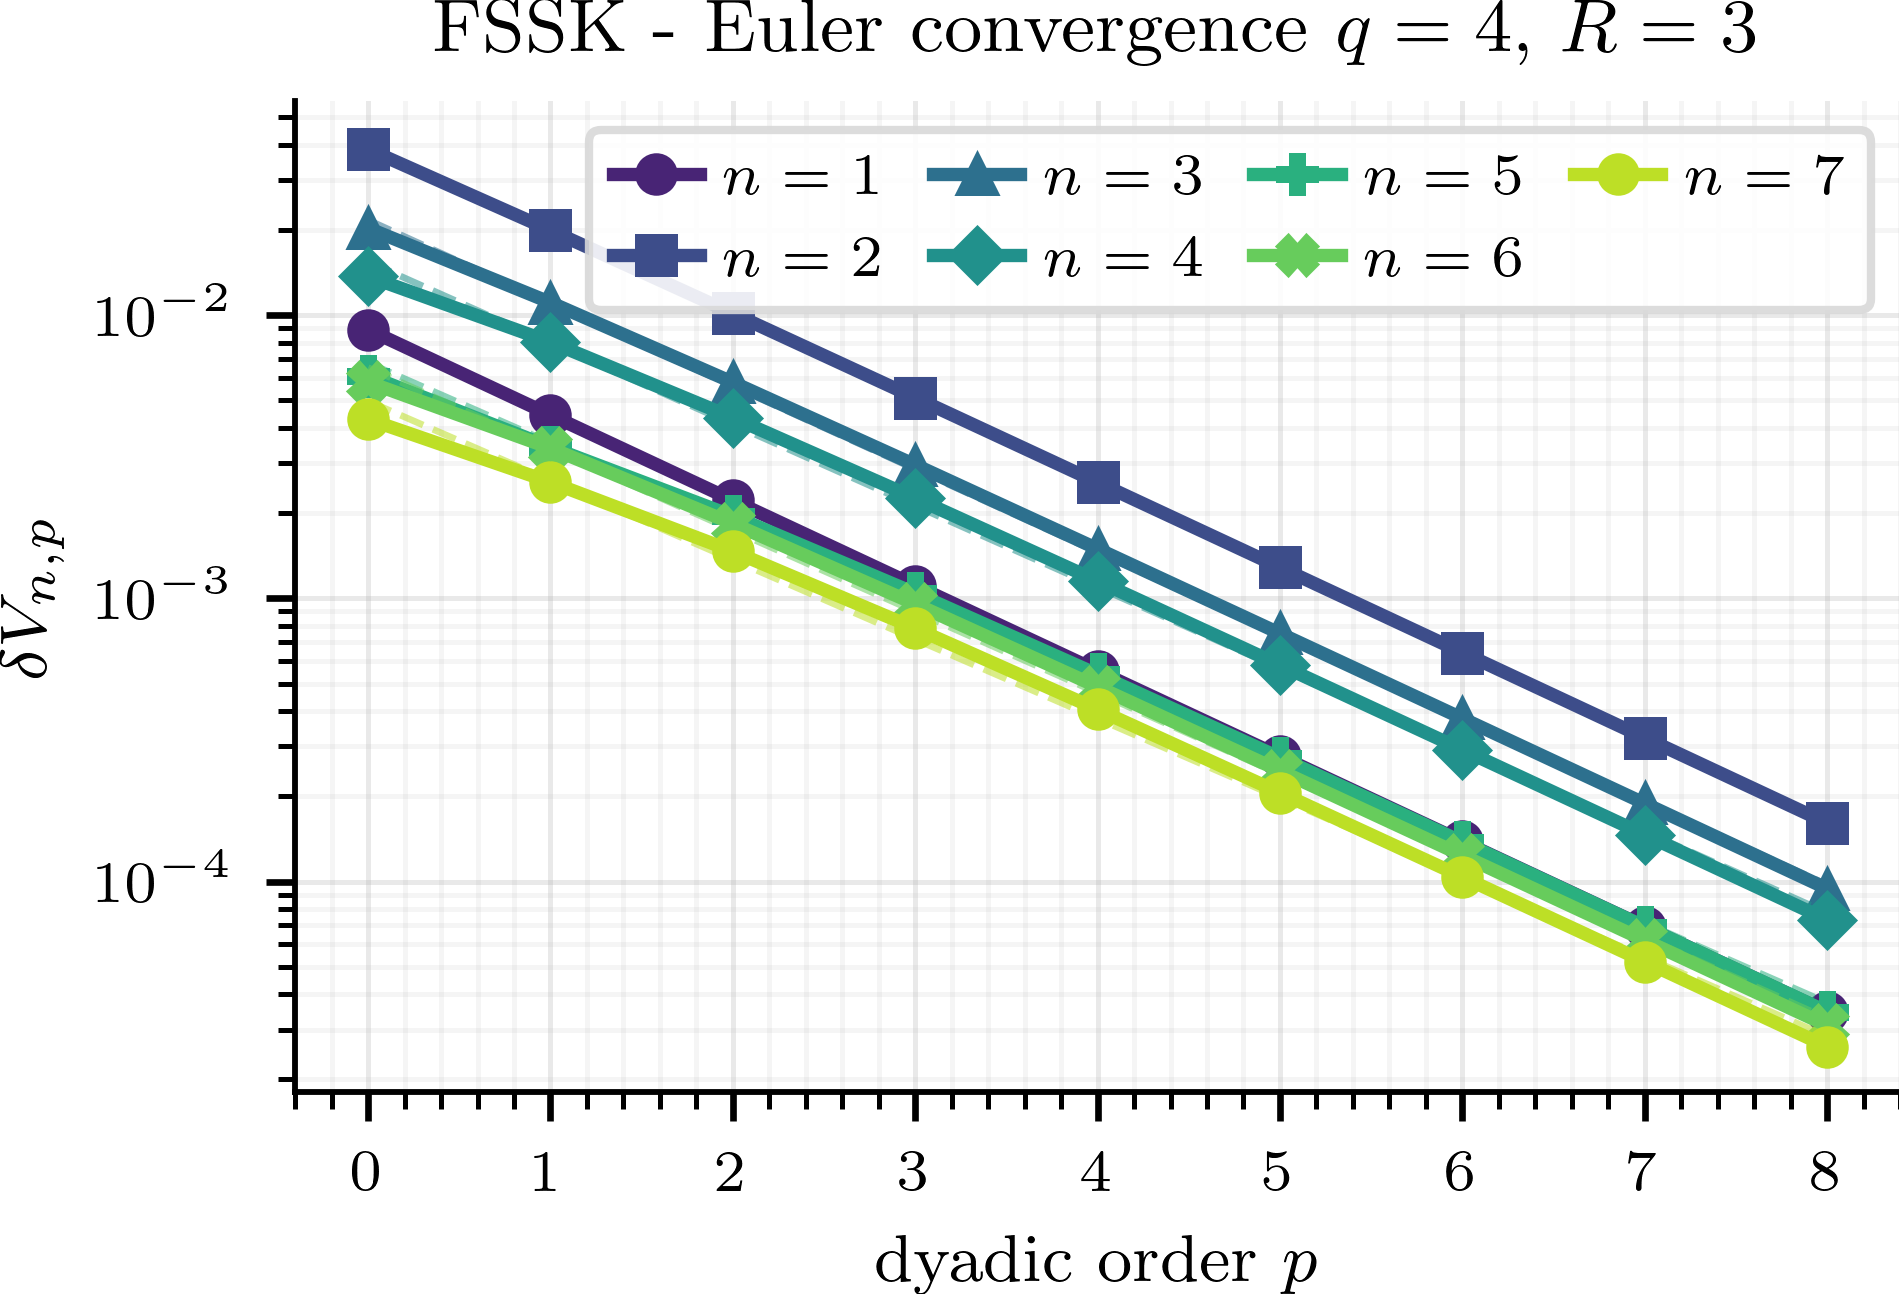

euler_conv_demo_q_1_R_1


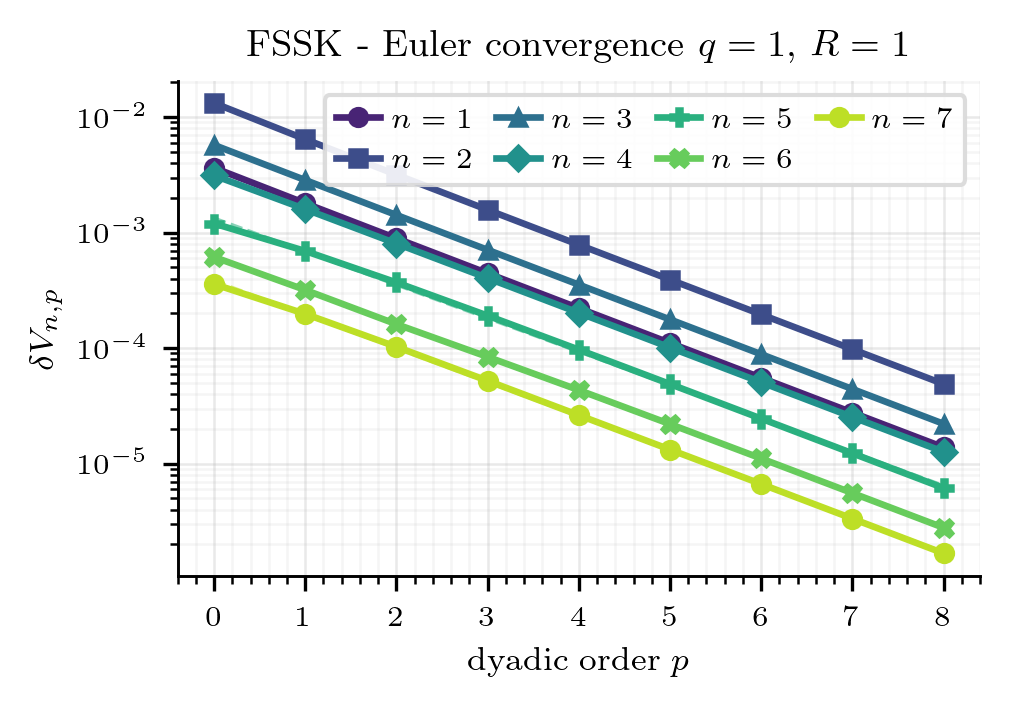

euler_conv_demo_q_2_R_2


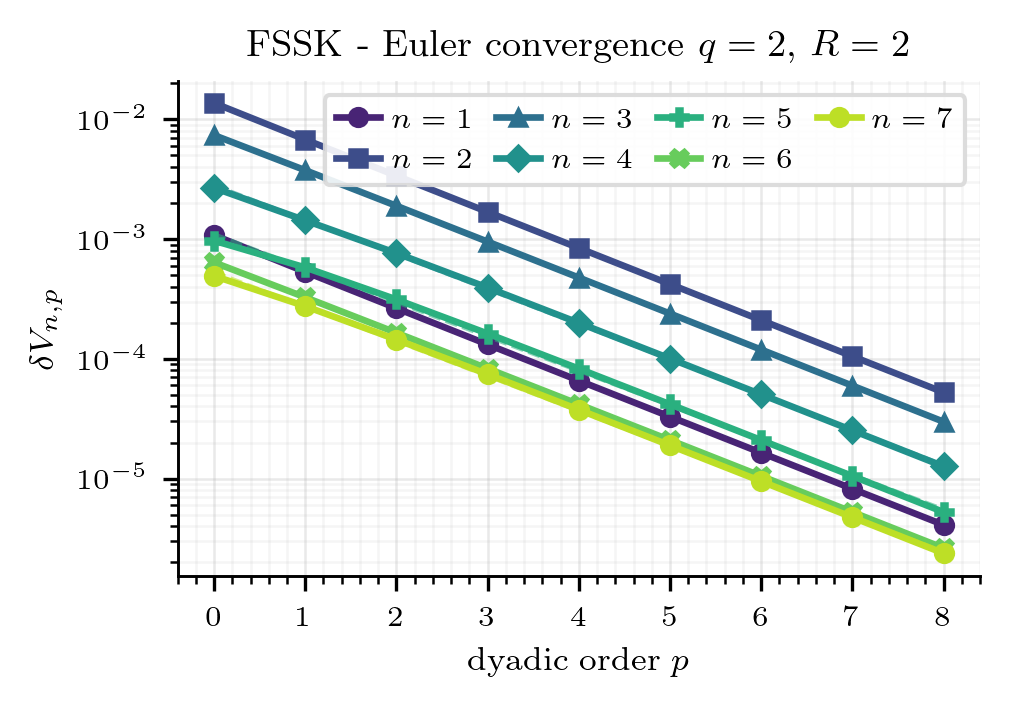

euler_conv_demo_q_4_R_3


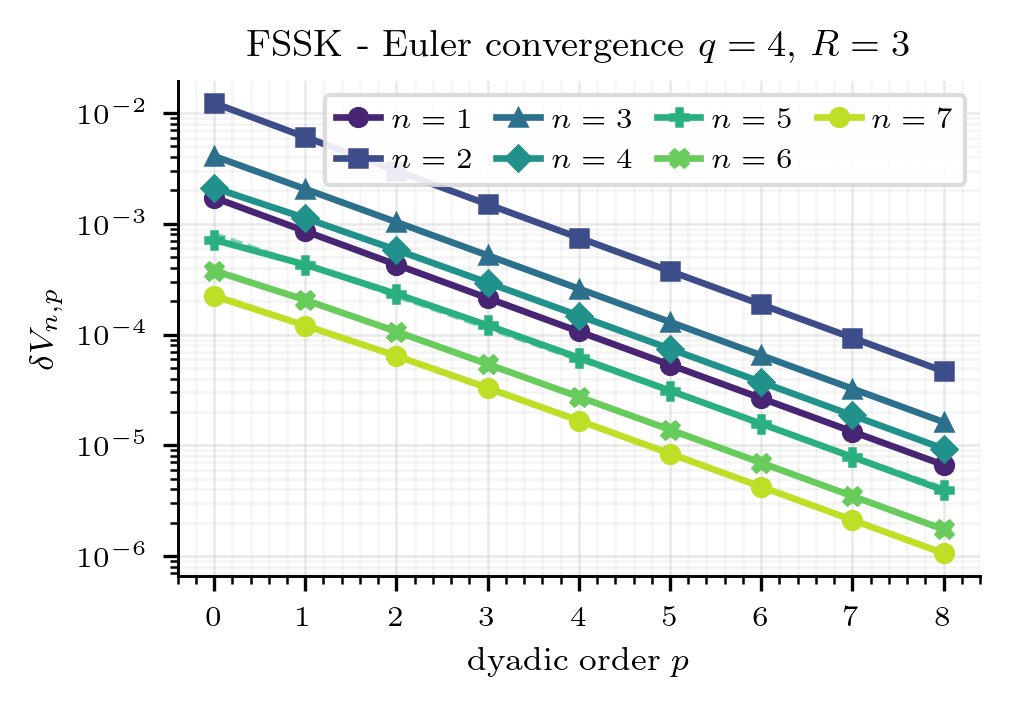

In [10]:
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

out = Path('validation') / OUTPUT_DIR

print('-- Convergence rates (fitted log2 slope per setup x level) --')
display(pd.read_csv(out / 'euler_conv_demo_rates.csv'))

print('\n-- Scaled max errors  n! * max|S^n_exact - S^n_Euler| --')
df_err = pd.read_csv(out / 'euler_conv_demo_errors.csv')
#display(df_err.pivot_table(index='dyadic_order', columns=['label', 'level'], values='scaled_max_error'))

for png in sorted(out.glob('euler_conv_demo_*.png')):
    print(png.stem)
    display(Image(filename=str(png)))

## 3a. FLOP scaling

he predicted work is

$$
W_q \;=\; (J-1)\,R^2\,
\begin{cases}
m^N & q = 1, \\
N\,m^N & q > 1.
\end{cases}
$$

We sweep over $(J, N, m, R, q)$ configurations, record the **XLA FLOP count** via
`jax.xla_computation`, and verify that $\mathrm{FLOPs} \propto W_q$ on log-log axes.

In [13]:
RUN_REGIME = "MEDIUM"   # SMALL | MEDIUM | LARGE

Loaded rows     : 1200
Valid FLOP rows : 1200
q values        : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
J values        : [np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(37), np.int64(41), np.int64(44), np.int64(53), np.int64(54), np.int64(59), np.int64(62), np.int64(63), np.int64(66), np.int64(67), np.int64(68), np.int64(70), np.int64(71), np.int64(76), np.int64(80), np.int64(82), np.int64(84), np.int64(86), np.int64(88), np.int64(91), np.int64(94), np.int64(95), np.int64(97), np.int64(100), np.int64(102), np.int64(104), np.int64(105), np.int64(106), np.int64(113), np.int64(115), np.int64(118), np.int64(119), np.int64(120), np.int64(121), np.int64(127), np.int64(132), np.int64(138), np.int64(140), np.int64(143), np.int64(144), np.int64(146), np.int64(147), np.int64(148), np.int64(151), np.int64(153), np.int64(157), np.int64(167), np.int64(169), np.int64(173), np.int64(175), np.int64(178), np.int64(189), np.int64(191), np.int64(194), np.int64(195), np.int

,q,n_points,W_min,W_max,flops_min,flops_max,pearson_log,spearman_log
0,1,300,492075.0,8.150337e+08,8040222.0,2.231371e+10,0.998223,0.997874
1,2,300,2460375.0,8.207575e+09,22832361.0,9.364167e+10,0.999464,0.999350
2,3,300,2460375.0,8.207575e+09,44729901.0,2.630972e+11,0.998327,0.998168
3,4,300,2460375.0,8.207575e+09,83628531.0,7.528155e+11,0.996391,0.996471


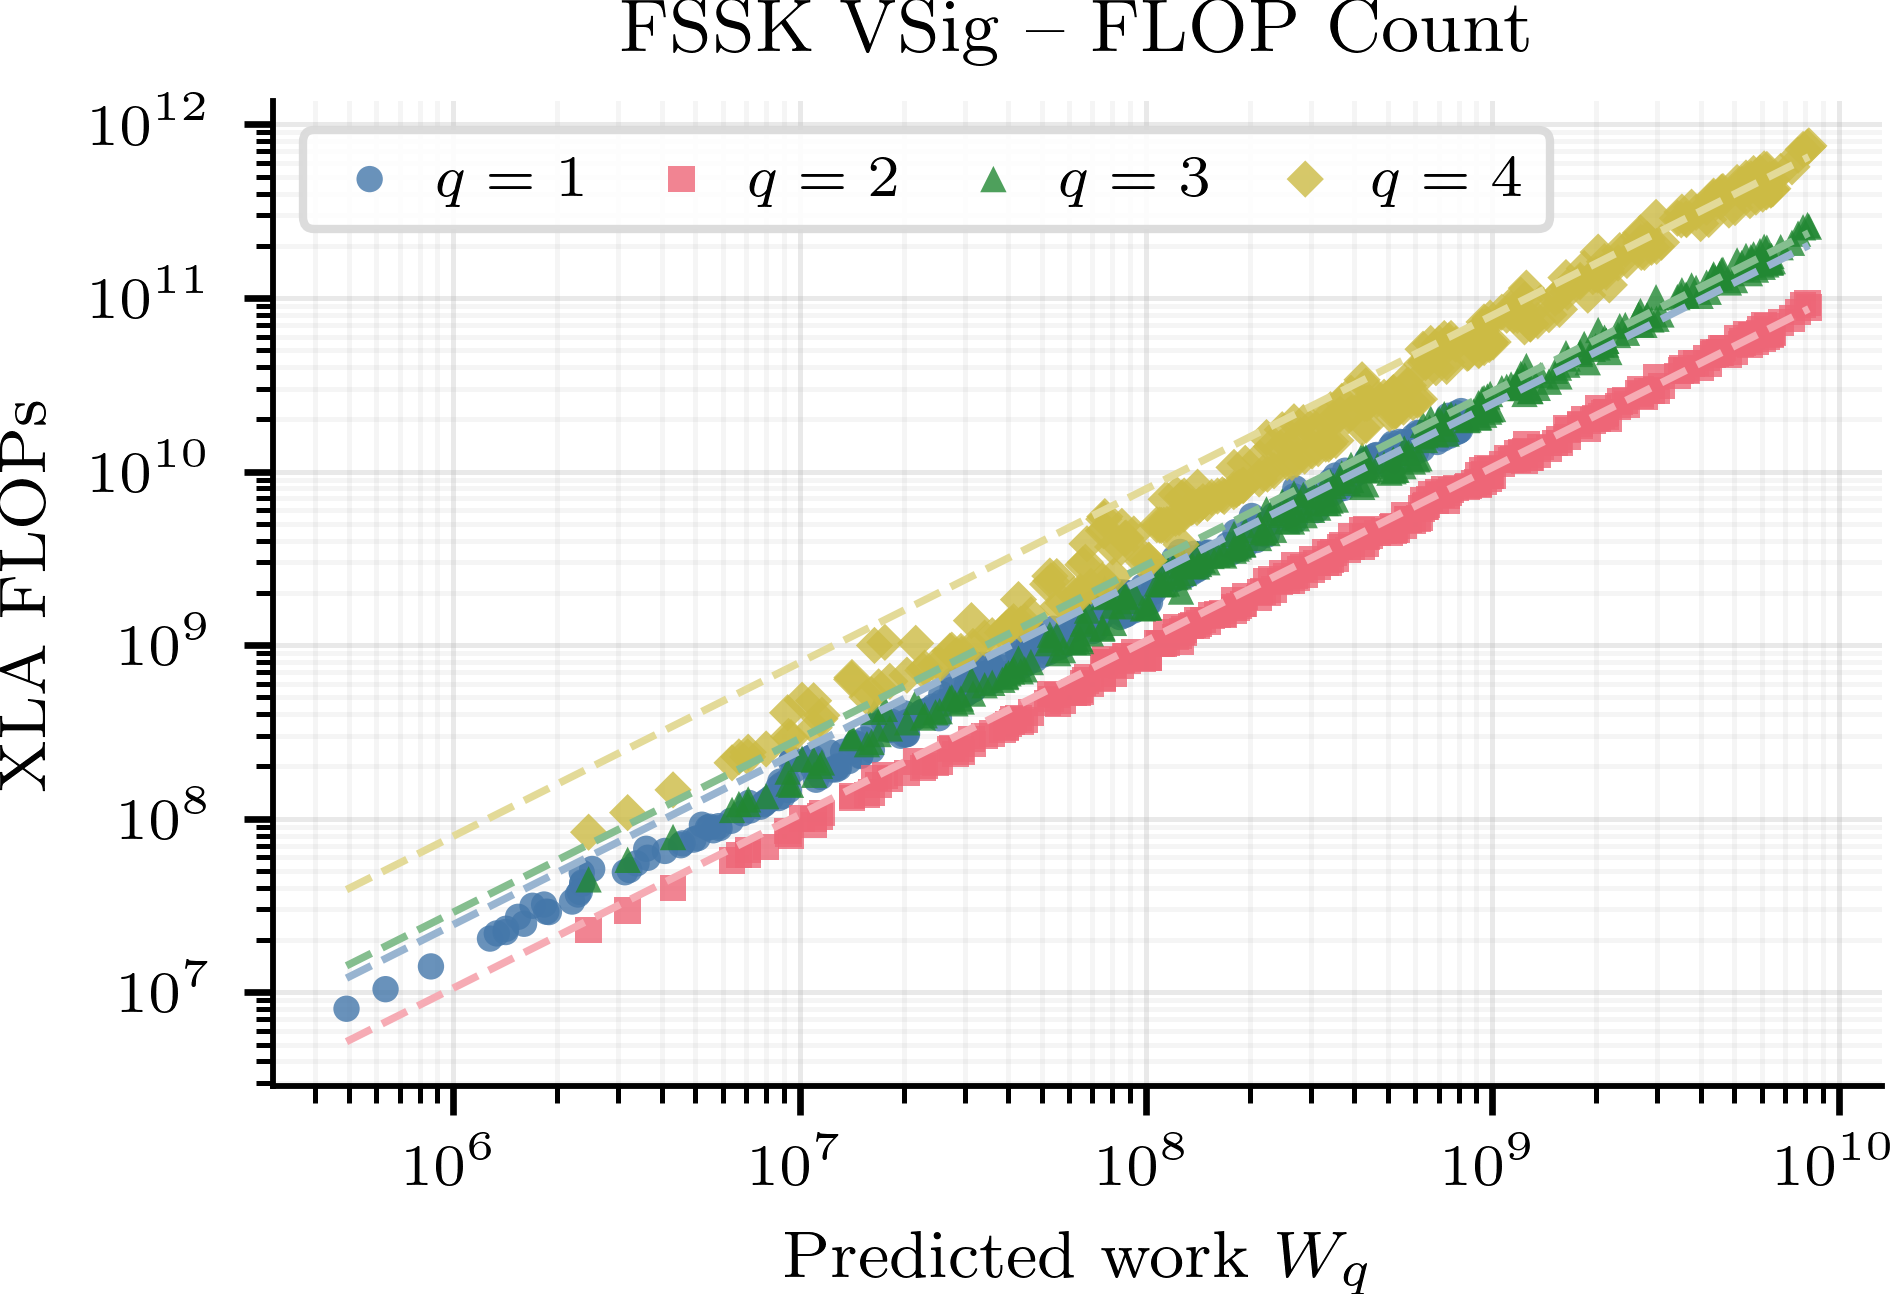

In [20]:
import subprocess, sys
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

tag = RUN_REGIME.lower()

script = Path('validation/analyse_flop_scaling.py').resolve()
result = subprocess.run(
    [sys.executable, str(script), '--regime', RUN_REGIME],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f'analyse_flop_scaling.py failed with exit code {result.returncode}')

out_dir = Path('validation/validation_outputs')

print('FLOP scaling summary (Spearman / Pearson log-correlation per n)')
display(pd.read_csv(out_dir / f'fssk_flop_scaling_{tag}_summary.csv'))

display(Image(filename=str(out_dir / f'fssk_flop_scaling_{tag}_xla_flops_vs_predicted_work.png')))

In [21]:
import pandas as pd
import numpy as np
from pathlib import Path

_pkl = Path('validation') / OUTPUT_DIR / f'fssk_flop_scaling_{RUN_REGIME.lower()}.pkl'
_df = pd.read_pickle(_pkl)
_sub = _df.dropna(subset=['xla_flops', 'coef_xla_flops']).copy()
_sub = _sub[(_sub['xla_flops'] > 0) & (_sub['coef_xla_flops'] > 0)]
_sub['coef_pct'] = 100 * _sub['coef_xla_flops'] / _sub['xla_flops']

print('Coefficient computation XLA FLOPs as % of total SSS FLOPs')
print(f'  Overall — median: {_sub["coef_pct"].median():.2f}%  '
      f'mean: {_sub["coef_pct"].mean():.2f}%  '
      f'max: {_sub["coef_pct"].max():.2f}%')
print()
_summary = (
    _sub.groupby('q')['coef_pct']
    .agg(median='median', mean='mean', max='max')
    .rename_axis('q')
    .reset_index()
)
display(_summary.style.format({'median': '{:.2f}%', 'mean': '{:.2f}%', 'max': '{:.2f}%'}))

Coefficient computation XLA FLOPs as % of total SSS FLOPs
  Overall — median: 0.02%  mean: 0.06%  max: 1.34%



,q,median,mean,max
0,1,0.01%,0.03%,0.34%
1,2,0.02%,0.05%,0.57%
2,3,0.03%,0.08%,0.96%
3,4,0.04%,0.11%,1.34%


## 3b. Coefficient computation FLOP scaling

The FSSK kernel evaluates signature coefficients $c_n(\Delta t)$ at each grid step.
The predicted computational work (Prop. cost\_fssk\_weights) differs by Lambda form:

$$
W_{\text{dense}} = R^3 + R^2 N^q, \qquad W_{\text{Jordan}} = R^2 N^q
$$

We sweep $(q, R, N)$ for both dense and Jordan-form $\Lambda$ and record XLA FLOPs.

In [17]:
# -- Parameters (edit here) --
RUN_REGIME_COEF = "MEDIUM"   # SMALL | MEDIUM | LARGE

Loaded rows     : 600
Valid FLOP rows : 600
q values        : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
R values        : [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
N values        : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Forms           : ['dense', 'jordan']

Summary:
  form  q  n_points  W_min     W_max  flops_min  flops_max  pearson_log  spearman_log
 dense  1        75   20.0    3312.0     6568.0   253666.0     0.979601      0.975505
 dense  2        75   44.0   19152.0    12862.0  2570942.0     0.993165      0.993300
 dense  3        75  116.0  193392.0    24302.0 16228558.0     0.999122      0.998947
 dense  4        75  332.0 2110032.0    42508.0 74990792.0     0.996238      0.996216
jordan  1        75   12.0    1584.0     6568.0   253666.0     0.995482      0.997319
jordan  2        7

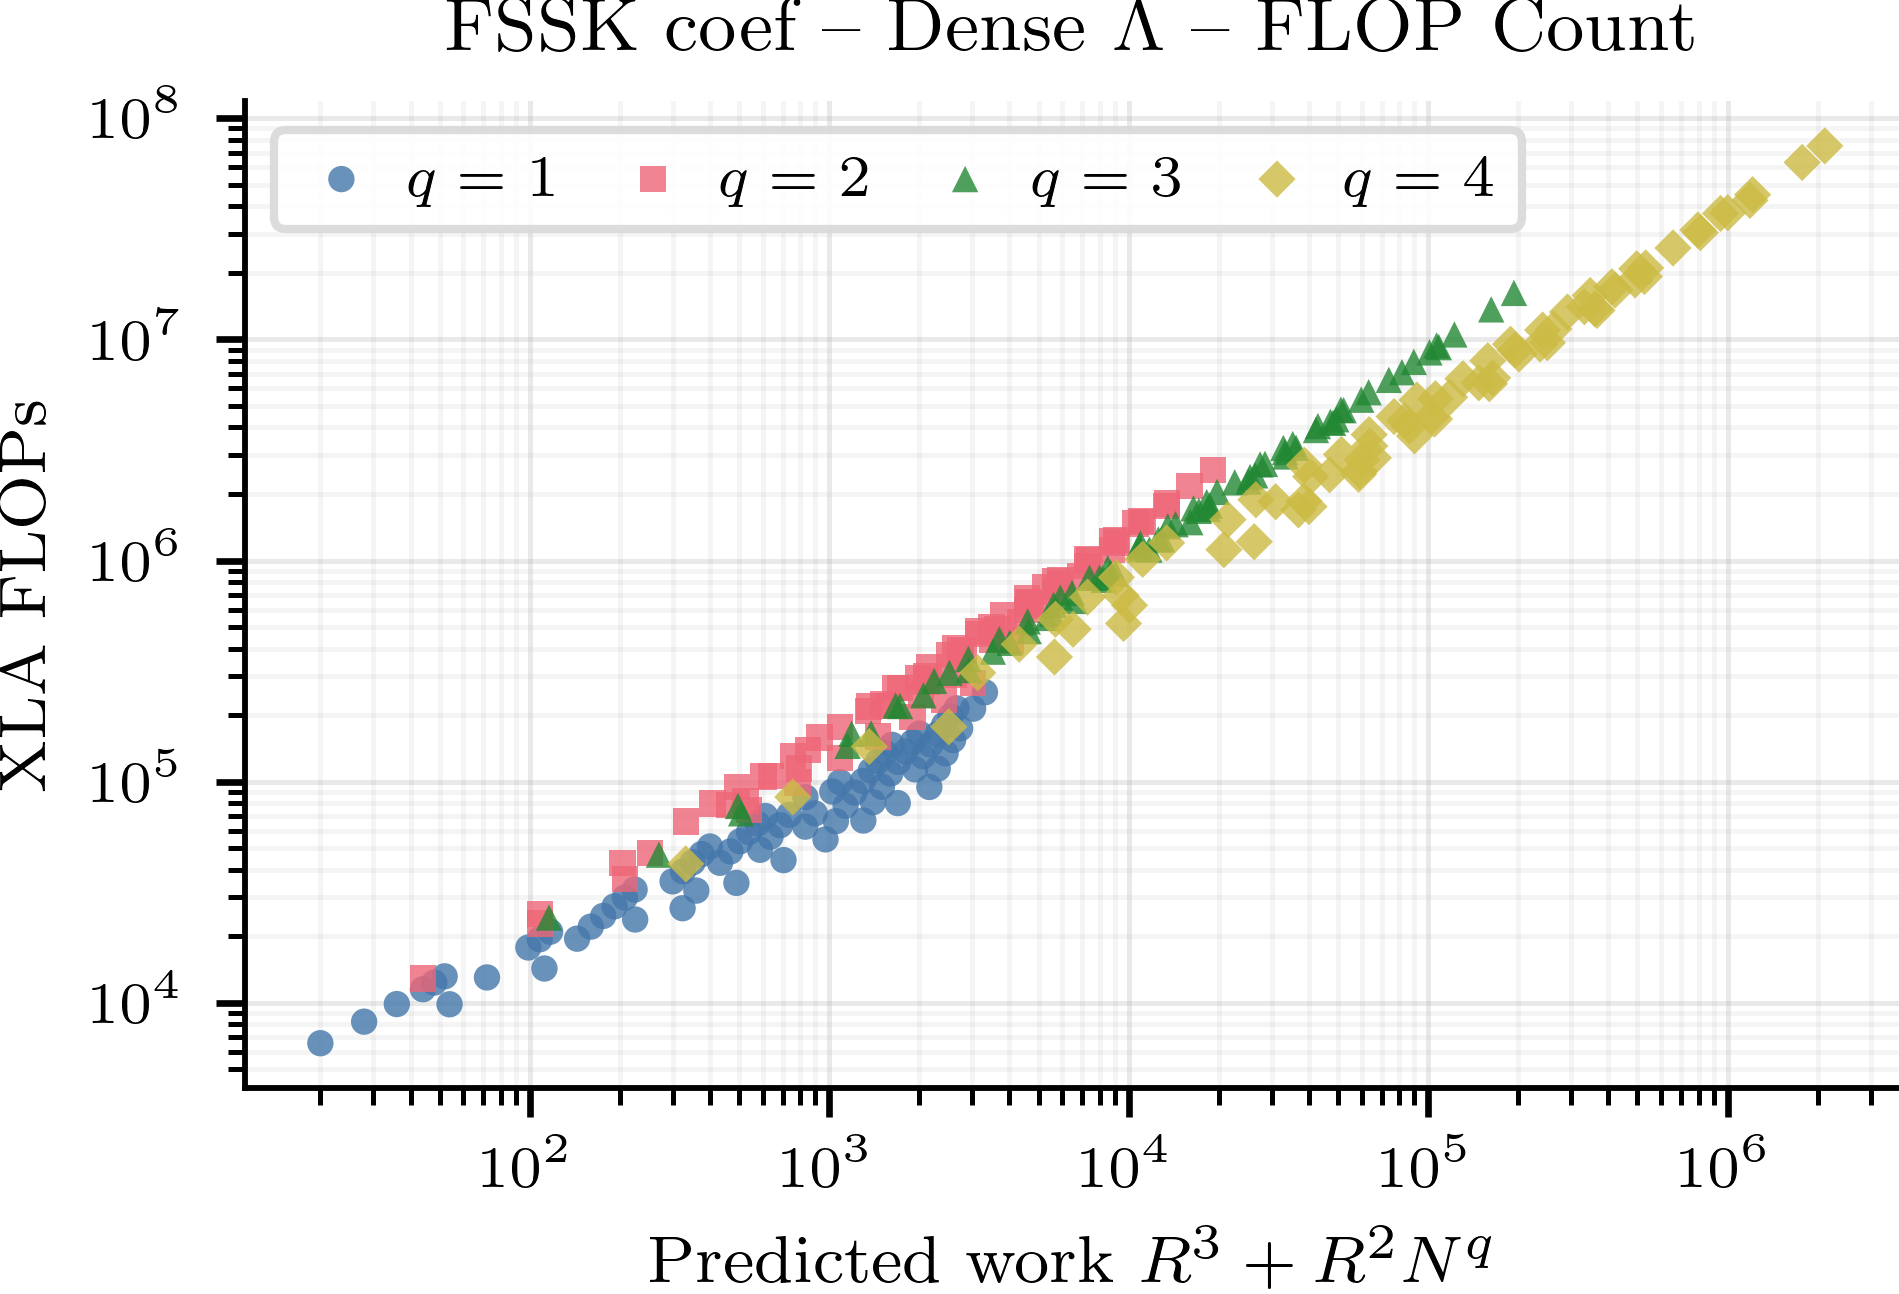

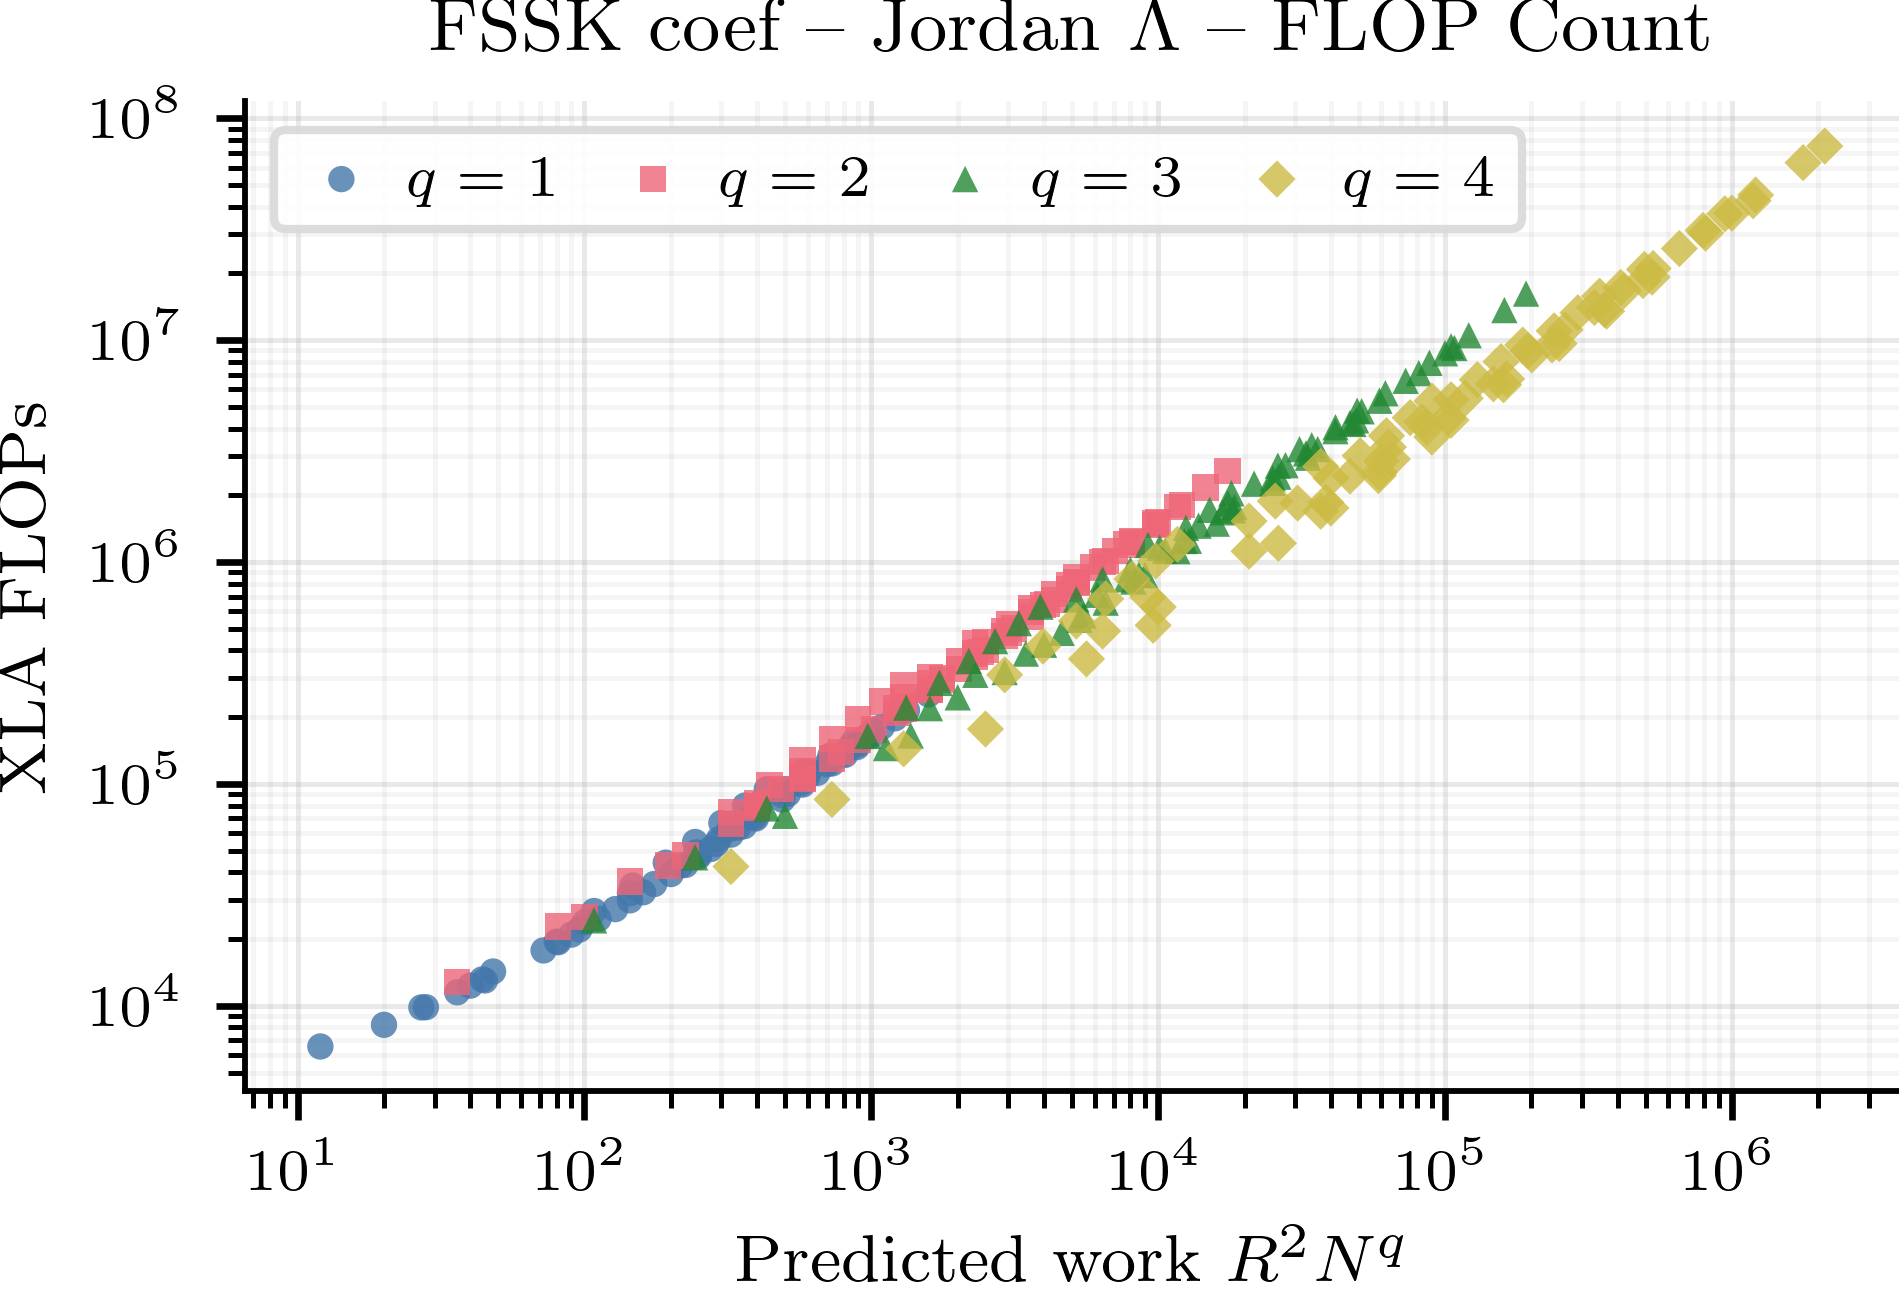

,form,q,n_points,W_min,W_max,flops_min,flops_max,pearson_log,spearman_log
0,dense,1,75,20.0,3312.0,6568.0,253666.0,0.979601,0.975505
1,dense,2,75,44.0,19152.0,12862.0,2570942.0,0.993165,0.993300
2,dense,3,75,116.0,193392.0,24302.0,16228558.0,0.999122,0.998947
3,dense,4,75,332.0,2110032.0,42508.0,74990792.0,0.996238,0.996216
4,jordan,1,75,12.0,1584.0,6568.0,253666.0,0.995482,0.997319
5,jordan,2,75,36.0,17424.0,12862.0,2570942.0,0.998222,0.998300
6,jordan,3,75,108.0,191664.0,24302.0,16228558.0,0.997162,0.997183
7,jordan,4,75,324.0,2108304.0,42508.0,74990792.0,0.995225,0.995299


In [19]:
import subprocess, sys
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

tag = RUN_REGIME_COEF.lower()

script = Path('validation/analyse_coef.py').resolve()
result = subprocess.run(
    [sys.executable, str(script), '--regime', RUN_REGIME_COEF],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f'analyse_coef.py failed (exit {result.returncode})')

out = Path('validation') / OUTPUT_DIR
for form in ['dense', 'jordan']:
    img = out / f'fssk_coef_scaling_{tag}_{form}_flops_vs_work.png'
    if img.exists():
        display(Image(str(img)))

csv_path = out / f'fssk_coef_scaling_{tag}_summary.csv'
if csv_path.exists():
    display(pd.read_csv(csv_path))

## 4. Wall-clock and CPU time vs. predicted work $W_q$

The theoretical cost model predicts that the hot-path runtime should scale as

$$
T_{\mathrm{hot}} \;\approx\; C_q \cdot W_q(J, R; N),
\qquad
W_q =
(J-1)\,R^2
\begin{cases}
m^N & q = 1,\\
N\,m^N & q > 1.
\end{cases}
$$

We verify this empirically by sweeping $(J, N, R, q, m)$ with the regime sampler,
timing the hot FSSK evaluation with `time.perf_counter` (wall) and
`time.process_time_ns` (CPU), and plotting both against $W_q$ on log-log axes.
A slope of $1$ on the log-log scale confirms the linear scaling prediction.

In [22]:
# -- Parameters (edit here) --
RUN_REGIME_TIMING = "MEDIUM"   # SMALL | MEDIUM | LARGE
TIMING_REPEATS    = None        # None = use regime default; or e.g. 5

Loaded 1200 rows from /Users/paulhager/PycharmProjects/levyMMD/tensordev/notebooks/sss/validation/validation_outputs/fssk_exact_scaling_timings_medium.pkl
q distribution:
   count
q       
1    300
2    300
3    300
4    300

Timing summary:
 q  n_points     W_min        W_max  wall_min  wall_max  spearman_log  pearson_log
 1       300 1233225.0  810152280.0  0.003417  2.241732      0.980805     0.979358
 2       300 6166125.0 8101522800.0  0.015050 13.823780      0.982635     0.982406
 3       300 6166125.0 8101522800.0  0.032764 14.014588      0.981266     0.979590
 4       300 6166125.0 8101522800.0  0.035374 29.088319      0.990655     0.984630

Saved: /Users/paulhager/PycharmProjects/levyMMD/tensordev/notebooks/sss/validation/validation_outputs/fssk_timing_summary_medium.csv

Wall/CPU ratio — median: 0.372  min: 0.173  max: 0.993
  Saved: /Users/paulhager/PycharmProjects/levyMMD/tensordev/notebooks/sss/validation/validation_outputs/fssk_wall_vs_work_medium.pdf
  Saved: /Users/paul

,q,n_points,W_min,W_max,wall_min,wall_max,spearman_log,pearson_log
0,1,300,1233225.0,8.101523e+08,0.003417,2.241732,0.980805,0.979358
1,2,300,6166125.0,8.101523e+09,0.015050,13.823780,0.982635,0.982406
2,3,300,6166125.0,8.101523e+09,0.032764,14.014588,0.981266,0.979590
3,4,300,6166125.0,8.101523e+09,0.035374,29.088319,0.990655,0.984630


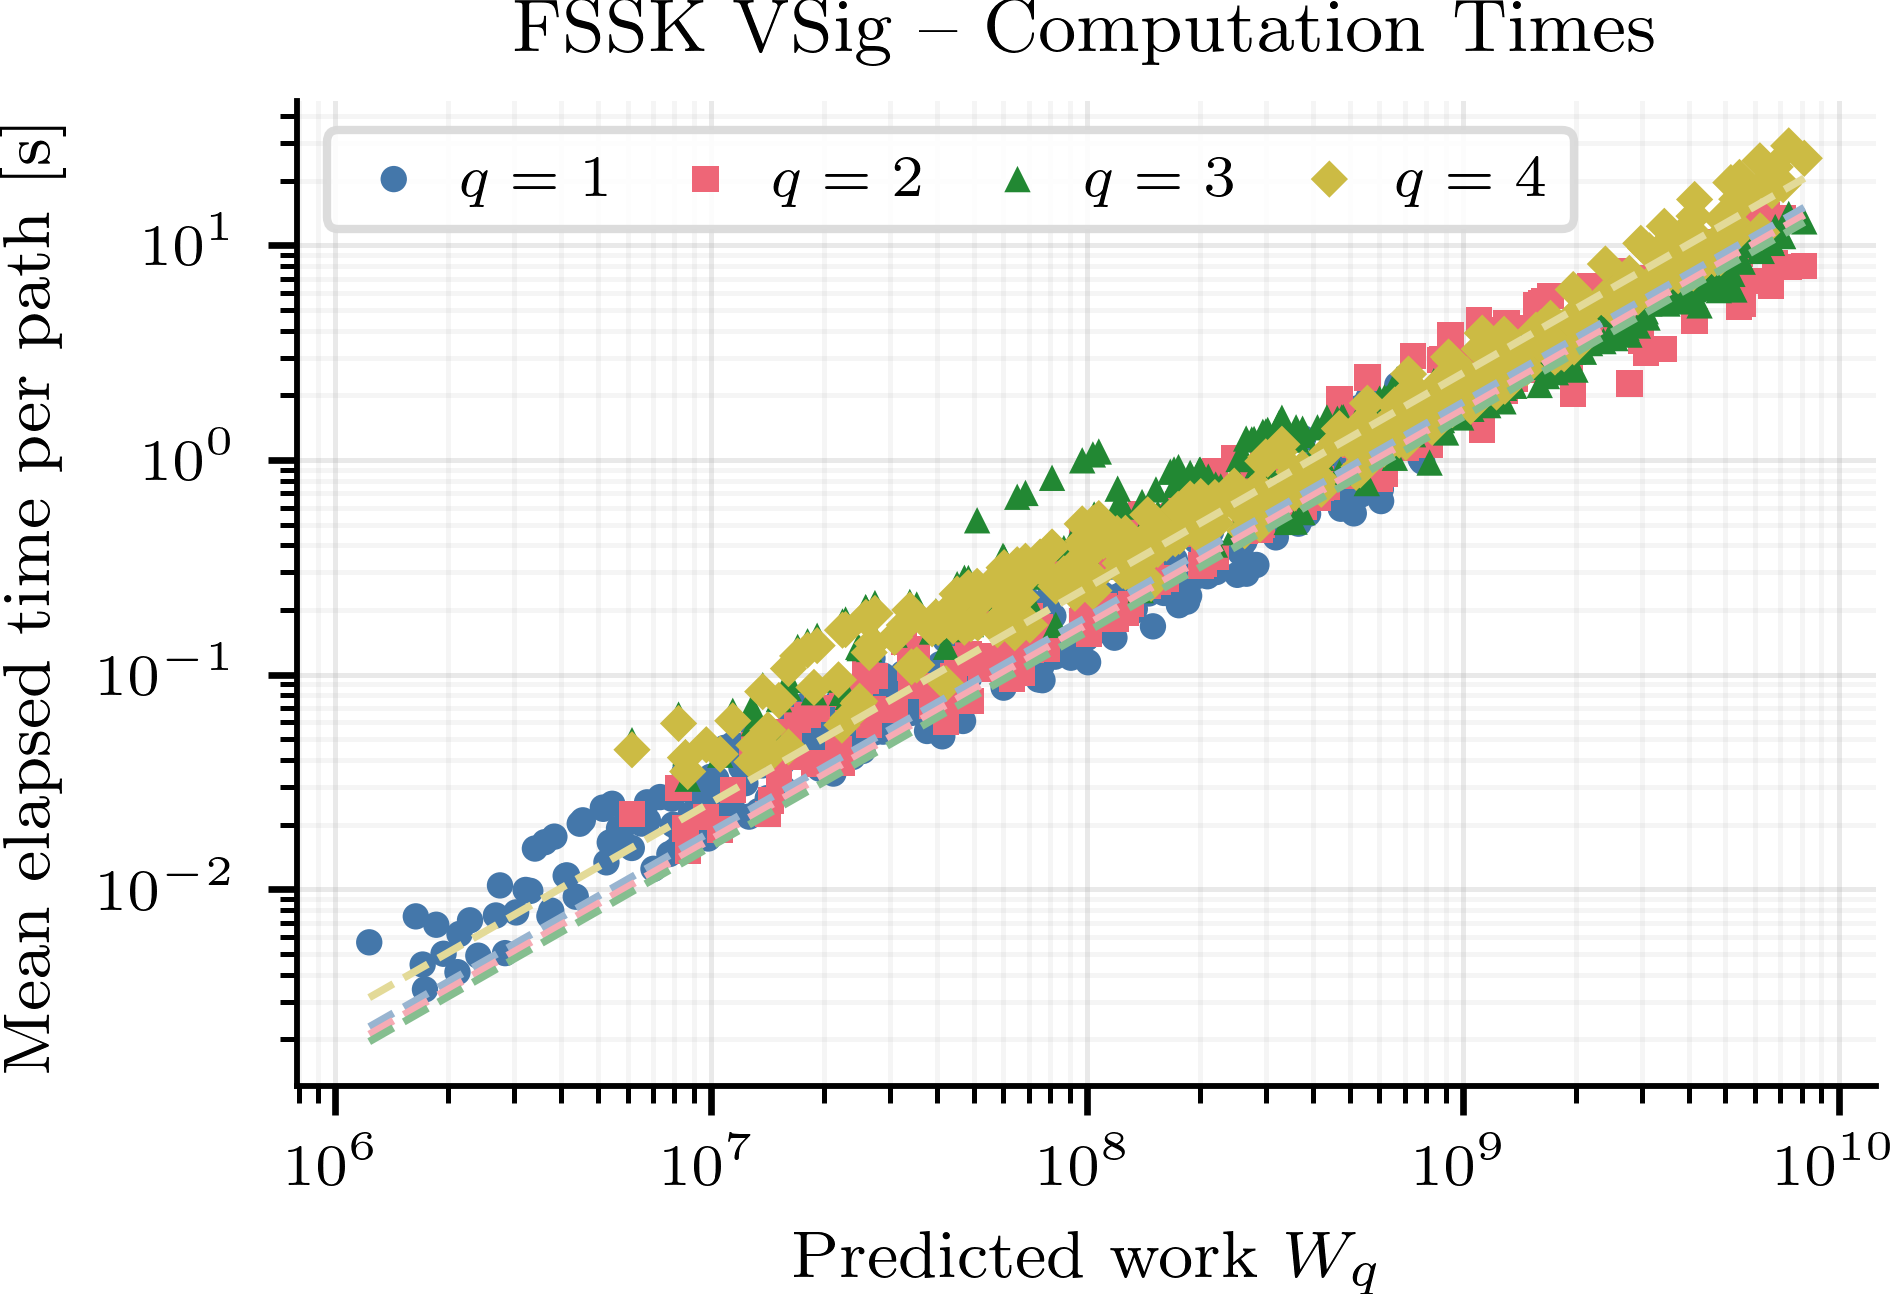

In [24]:
import subprocess, sys
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

script = Path('validation/analyse_timing.py').resolve()
result = subprocess.run(
    [sys.executable, str(script), '--regime', RUN_REGIME_TIMING],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f'analyse_timing.py failed with exit code {result.returncode}')

tag = RUN_REGIME_TIMING.lower()
out_dir = Path('validation/validation_outputs')

display(pd.read_csv(out_dir / f'fssk_timing_summary_{tag}.csv'))
display(Image(filename=str(out_dir / f'fssk_wall_vs_work_{tag}.png')))